# Case Study_Human Resourse Dataset

* <b>Human_Resources.csv<b/> Analysis
* Apply K mean Clustering
* Apply PCA
* Apply Autoencoder

## Task 1:Import your libraries (Lab 2)

In [97]:
#Import the libraries here
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder

In [98]:
#Attach the Human_Resource.csv file and view the first five records
df = pd.read_csv("Human_Resources.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [99]:
# show all the file data types
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [100]:
# Show the following basic statistics
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Task 2: Visualize Dataset (Lab 2)

In [101]:
# Replace 'Attritition','Overtime' and 'Over18' columns with integers before performing any visualizations
binary_columns = ['Attrition', 'OverTime']

for col in binary_columns:
  df[col] = df[col].map({'Yes': 1, 'No': 0})
  
df[binary_columns].head()

,Attrition,OverTime
0,1,1
1,0,0
2,1,1
3,0,1
4,0,0


In [102]:
df['Over18'] = df['Over18'].map({'Y': 1, 'N': 0})
df['Over18'].head()

0    1
1    1
2    1
3    1
4    1
Name: Over18, dtype: int64

In [103]:
# display the current first four records
df.head(4)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0


In [104]:
# Drop EmployeeNumber',EmployeeCount' ,'Standardhours' and 'Over18' since they do not change from one employee to the other
df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'StandardHours', 'Over18'], inplace=True)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [105]:
# Let's see how many employees left the company!
left_df = df[df['Attrition'] == 1]
stayed_df = df[df['Attrition'] == 0]
print("Employees who left:", left_df.shape[0])
print("----")
print("Employees who stayed:", stayed_df.shape[0])

Employees who left: 237
----
Employees who stayed: 1233


In [106]:
# Count the number of employees who stayed and left
# It seems that we are dealing with an imbalanced dataset
attrition_percent = df['Attrition'].value_counts(normalize=True) * 100
attrition_percent

Attrition
0    83.877551
1    16.122449
Name: proportion, dtype: float64

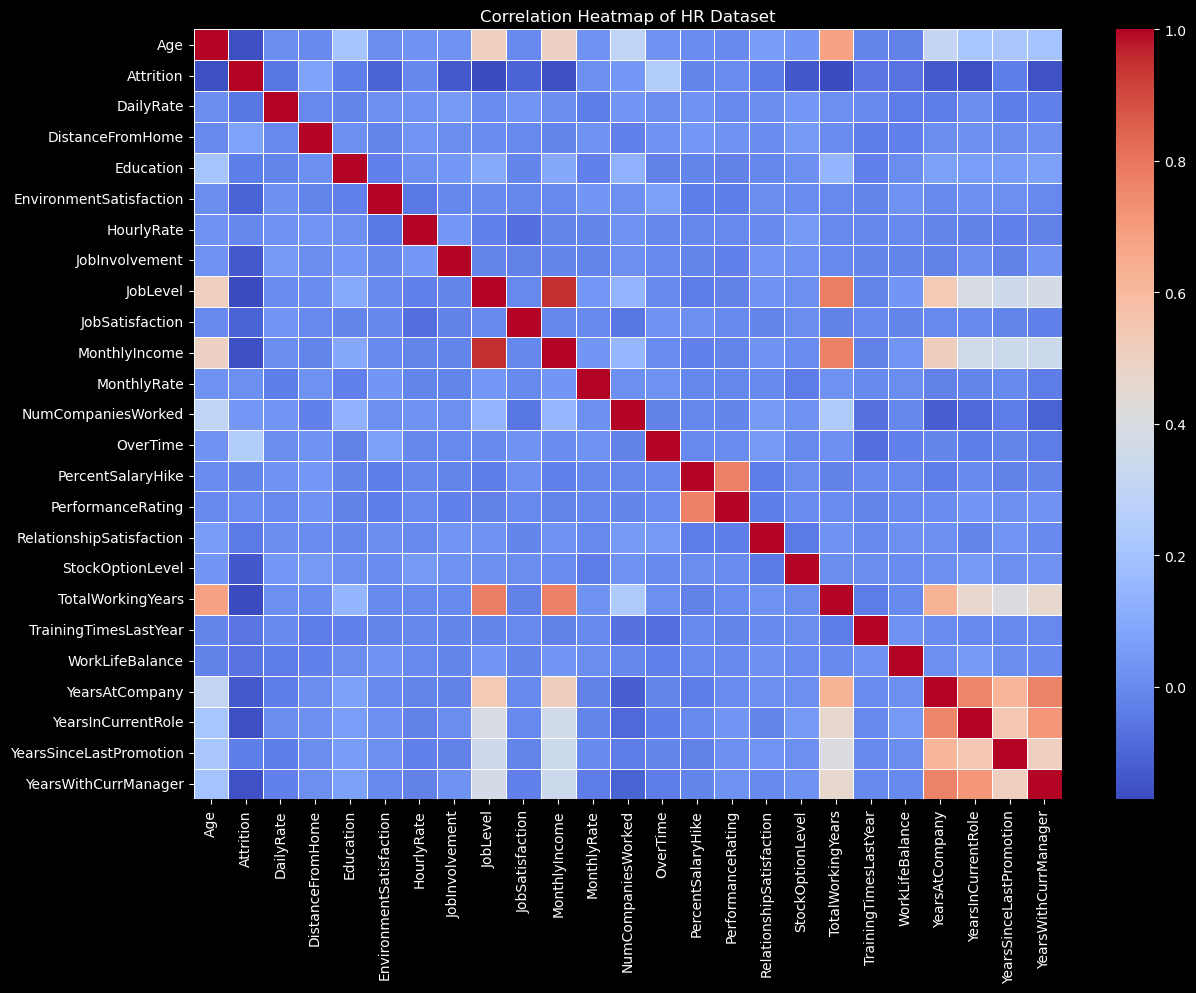

In [107]:
# show the correlation heat map as below
corr_matrix = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
corr_matrix,
cmap='coolwarm',
annot=False,
linewidths=0.5
)

plt.title('Correlation Heatmap of HR Dataset')
plt.show()

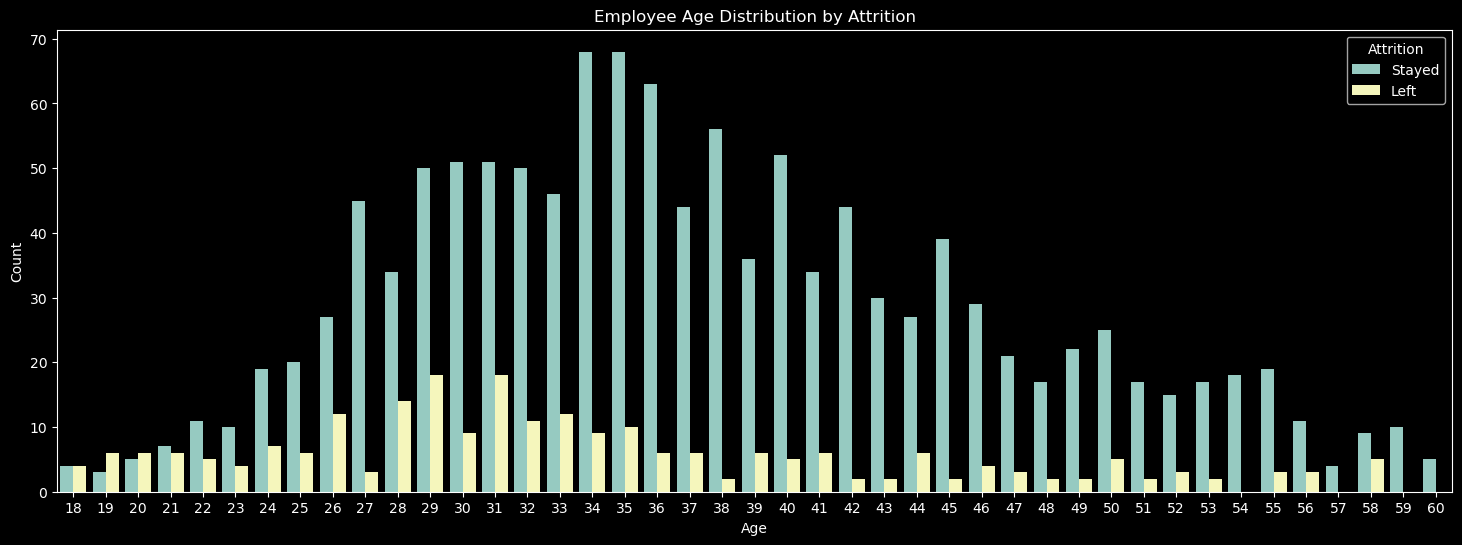

In [108]:
# Display the below visualization with hue as Attrition
plt.figure(figsize=(18, 6))

sns.countplot(
    x='Age',
    data=df,
    hue='Attrition'
)

plt.title('Employee Age Distribution by Attrition')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Attrition', labels=['Stayed', 'Left'])
plt.show()

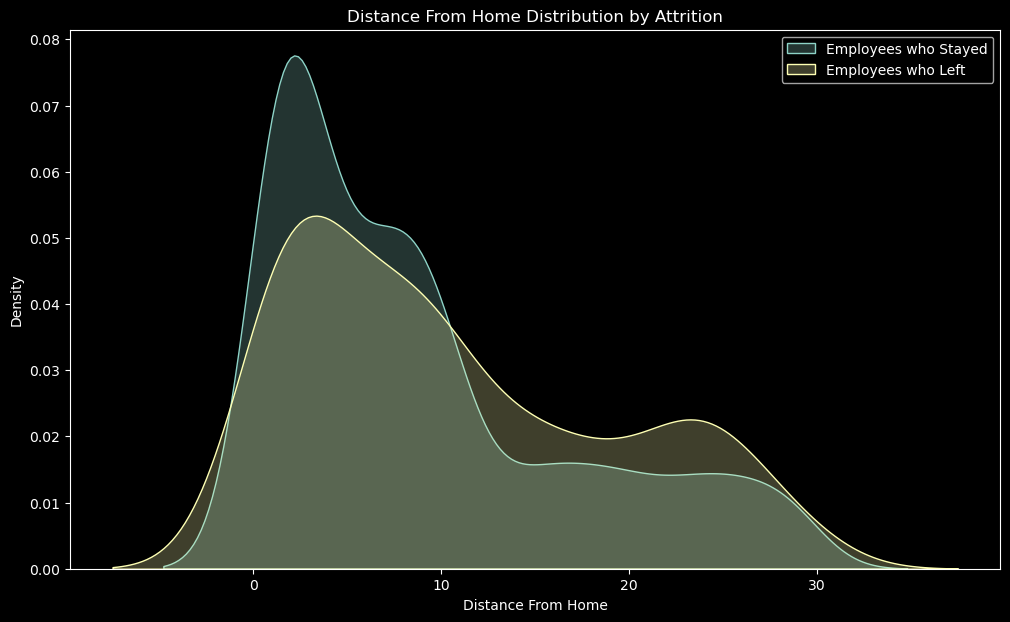

In [109]:
# create a Kernel Density Estimate comparing 'Employees who left' and 'Employees who Stayed' using 'Distance From Home'
plt.figure(figsize=(12, 7))

sns.kdeplot(
    df[df['Attrition'] == 0]['DistanceFromHome'],
    label='Employees who Stayed',
    fill=True
)
sns.kdeplot(
    df[df['Attrition'] == 1]['DistanceFromHome'],
    label='Employees who Left',
    fill=True
)
plt.title('Distance From Home Distribution by Attrition')
plt.xlabel('Distance From Home')
plt.ylabel('Density')
plt.legend()
plt.show()

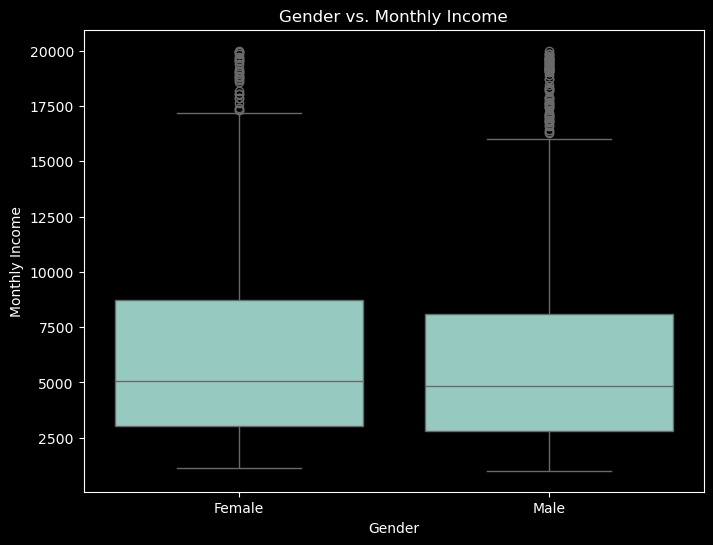

In [110]:
# Let's see the Gender vs. Monthly Income using box plots
plt.figure(figsize=(8,6))
sns.boxplot(x='Gender', y='MonthlyIncome', data=df)
plt.title('Gender vs. Monthly Income')
plt.ylabel('Monthly Income')
plt.xlabel('Gender')
plt.show()

## Task 3: Create Testing and Training Dataset & Perform Data Cleaning (Lab 2)

In [111]:
# Convert the categorical fields into numerics using OneHotEncoder
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Categorical columns:")
print(categorical_cols)

encoder = OneHotEncoder(sparse_output=False, drop=None) 

encoded_array = encoder.fit_transform(df[categorical_cols])
encoded_cols = encoder.get_feature_names_out(categorical_cols)
encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
numeric_df = df.drop(categorical_cols, axis=1)
final_df = pd.concat([numeric_df, encoded_df], axis=1)

print(final_df.head())

Categorical columns:
Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus'],
      dtype='object')
   Age  Attrition  DailyRate  DistanceFromHome  Education  \
0   41          1       1102                 1          2   
1   49          0        279                 8          1   
2   37          1       1373                 2          2   
3   33          0       1392                 3          4   
4   27          0        591                 2          1   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                        2          94               3         2   
1                        3          61               2         2   
2                        4          92               2         1   
3                        4          56               3         1   
4                        1          40               3         1   

   JobSatisfaction  ...  JobRole_Laboratory Technician  JobRole_Manager  \
0  

In [112]:
# select your features here i.e. drop the target 'Atrittion'

X = final_df.drop('Attrition', axis=1)
y = final_df['Attrition'] 

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1470, 50)
Target shape: (1470,)


In [113]:
# scale your features data assigning it variable X

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
print(X_scaled.head())
print("Scaled features shape:", X_scaled.shape)

        Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0  0.446350   0.742527         -1.010909  -0.891688                -0.660531   
1  1.322365  -1.297775         -0.147150  -1.868426                 0.254625   
2  0.008343   1.414363         -0.887515  -0.891688                 1.169781   
3 -0.429664   1.461466         -0.764121   1.061787                 1.169781   
4 -1.086676  -0.524295         -0.887515  -1.868426                -1.575686   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0    1.383138        0.379672 -0.057788         1.153254      -0.108350  ...   
1   -0.240677       -1.026167 -0.057788        -0.660853      -0.291719  ...   
2    1.284725       -1.026167 -0.961486         0.246200      -0.937654  ...   
3   -0.486709        0.379672 -0.961486         0.246200      -0.763634  ...   
4   -1.274014        0.379672 -0.961486        -0.660853      -0.644858  ...   

   JobRole_Laboratory Technician  JobR

In [114]:
X

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single
0,41,1102,1,2,2,94,3,2,4,5993,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,279,8,1,3,61,2,2,2,5130,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,37,1373,2,2,4,92,2,1,3,2090,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,33,1392,3,4,4,56,3,1,3,2909,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,27,591,2,1,1,40,3,1,2,3468,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,2,3,41,4,2,4,2571,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1466,39,613,6,1,4,42,2,3,1,9991,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1467,27,155,4,3,2,87,4,2,2,6142,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1468,49,1023,2,3,4,63,2,2,2,5390,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [115]:
# select your dependent, target or response data as "Attrition" using variable y
print(y.head())
print("Target shape:", y.shape)

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64
Target shape: (1470,)


In [116]:
y

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

## Task 4: Find the Optimal Number of Clusters using Elblow Method (Lab 2)

In [117]:
# Compute 'within cluster sum of squares' or WCSS metric for a range of k clusters
inertia_values = []
training_range = range(1, 14) 

for i in training_range:
  model = KMeans(n_clusters=i, random_state=77)
  model.fit(X_scaled) 
  inertia_values.append(model.inertia_)


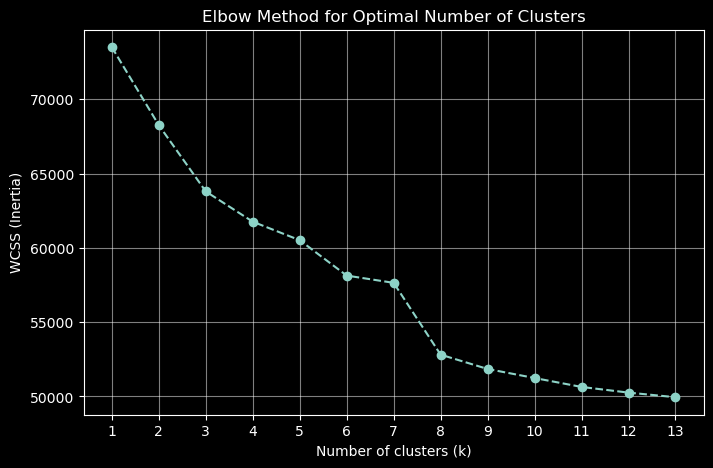

In [118]:
# Create a visualization for Finding the right number of clusters - Elbow method'
plt.figure(figsize=(8,5))
plt.plot(training_range, inertia_values, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(training_range)
plt.grid(True, alpha=0.5)
plt.show()

## Task 5: Apply K-Means Clustering (Lab 2)

In [119]:
final_model = KMeans(n_clusters=6, random_state=77)
final_model.fit(X_scaled)

KMeans(n_clusters=6, random_state=77)

In [120]:
df["clusters"] = final_model.labels_
df["clusters"].head()

0    3
1    1
2    1
3    2
4    1
Name: clusters, dtype: int32

Size of each cluster:
0    191
1    351
2    198
3    322
4    273
5    135
Name: count, dtype: int64


/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_36154/3490013697.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='viridis')


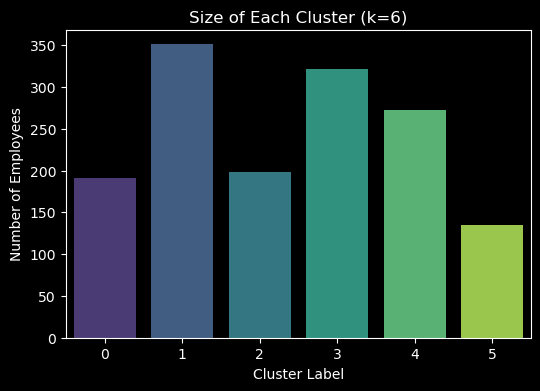

In [121]:
# Check size of each cluster - Are they all representative ?

optimal_k = 6
cluster_labels = final_model.fit_predict(X_scaled)

cluster_sizes = pd.Series(cluster_labels).value_counts().sort_index()
print("Size of each cluster:")
print(cluster_sizes)

plt.figure(figsize=(6,4))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, palette='viridis')
plt.title(f'Size of Each Cluster (k={optimal_k})')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Employees')
plt.show()

## Task 6: Apply PCA and Visualize Results (Lab 3)


In [145]:
# Obtain the principal components
from sklearn.decomposition import PCA

In [146]:
# All samples projected on the two principal components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [147]:
# Create a dataframe with the two components
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=X_scaled.index)

In [148]:
# Concatenate the clusters labels to the dataframe
pca_df['Cluster'] = cluster_labels

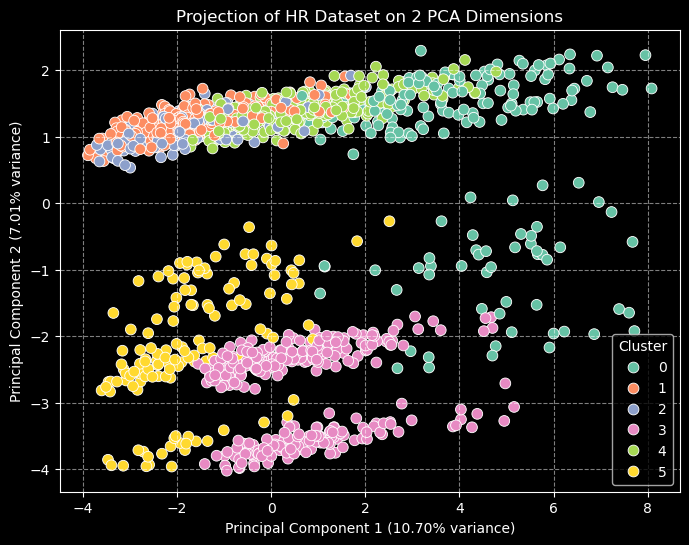

In [149]:
# Create a scatterplot visual of Projection of the dataset on the 2 PCA dimensions'
plt.figure(figsize=(8,6))
sns.scatterplot(
x='PC1',
y='PC2',
hue='Cluster',
data=pca_df,
palette='Set2',
s=60
)
plt.title('Projection of HR Dataset on 2 PCA Dimensions')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [150]:
# show the % of the total variance explained by each principal component. Overall close to 48% explained by these two.
explained_variance = pca.explained_variance_ratio_
print(f"Variance explained by PC1: {explained_variance[0]*100:.2f}%")
print(f"Variance explained by PC2: {explained_variance[1]*100:.2f}%")
print(f"Total variance explained by 2 PCs: {explained_variance.sum()*100:.2f}%")

Variance explained by PC1: 10.70%
Variance explained by PC2: 7.01%
Total variance explained by 2 PCs: 17.72%


## Task 7: Perform Dimensionality Reduction using Autoencoders (Lab 3)

In [166]:
#import the autoencoder libraries
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam


In [167]:
# create your autoencoder with all the features showing Encoder, bottleneck, decoder, autoencoder
# compile the autoencoder using optimizer='adam', loss='mean_squared_error'

input_dim = X_scaled.shape[1] 

encoding_dim = 10  

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
output_layer = Dense(input_dim, activation='linear')(decoded)

# Autoencoder model
autoencoder = Model(inputs=input_layer, outputs=output_layer)

# Encoder model (to get reduced dimensions)
encoder = Model(inputs=input_layer, outputs=bottleneck)

# Compile autoencoder
autoencoder.compile(optimizer=Adam(), loss='mean_squared_error')


In [168]:
# show the autoencoder summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         3,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,388 (44.48 KB)

 Trainable params: 11,388 (44.48 KB)

 Non-trainable params: 0 (0.00 B)

In [169]:
## Train autoencoder using input = output
history = autoencoder.fit(
X_scaled, X_scaled, 
epochs=50, 
batch_size=32,
validation_split=0.2,
shuffle=True,
verbose=1
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.9799 - val_loss: 0.9690
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.8946 - val_loss: 0.8847
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8204 - val_loss: 0.8208
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7630 - val_loss: 0.7544
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7111 - val_loss: 0.7066
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6720 - val_loss: 0.6653
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6379 - val_loss: 0.6332
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6066 - val_loss: 0.6084
Epoch 9/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5816 - val_loss: 0.5907
Epoch 10/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5609 - val_loss: 0.5723
Epoch 11/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5448 - val_loss: 0.5583
Epoch 12/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5314 - val_lo

In [170]:
# Use Autoencoder to reduce the number of features / dimensions and show the dimensions
X_reduced = encoder.predict(X_scaled)

print("Original features shape:", X_scaled.shape)
print("Reduced features shape:", X_reduced.shape)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Original features shape: (1470, 50)
Reduced features shape: (1470, 10)


## Task 8: Apply KMEANS to encoded dataset (Lab 3)

In [174]:
# Apply KMEANS to encoded dataset here
k_range = range(1, 14)
wcss_reduced = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=77)
    kmeans.fit(X_reduced)
    wcss_reduced.append(kmeans.inertia_)



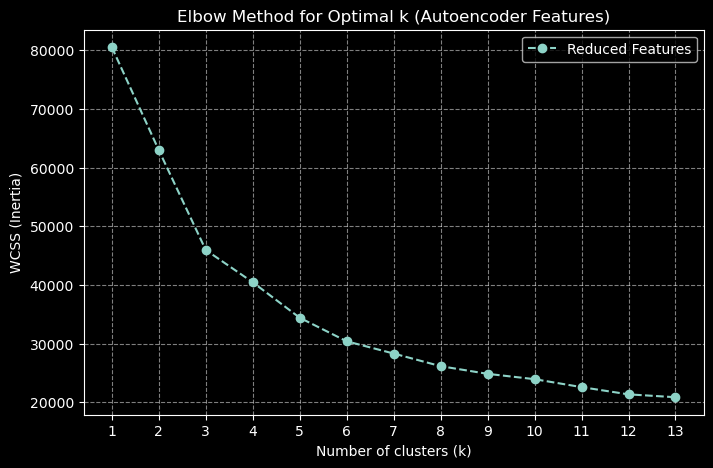

In [175]:
# create a line plot to show the " Pick optimal number of clusters using Elbow method" of the unreduced and reduced dimension Kmeans features
plt.figure(figsize=(8,5))
plt.plot(k_range, wcss_reduced, marker='o', linestyle='--', label='Reduced Features')
plt.title('Elbow Method for Optimal k (Autoencoder Features)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [181]:
## Apply the resulting optimal k to find new centroids
optimal_k = 6

kmeans_reduced = KMeans(n_clusters=optimal_k, random_state=77)
cluster_labels_reduced = kmeans_reduced.fit_predict(X_reduced)


In [182]:
## Show the centroids shape
print("Centroids shape:", kmeans_reduced.cluster_centers_.shape)

Centroids shape: (6, 10)


In [183]:
# show the clusters shape
print("Cluster labels shape:", cluster_labels_reduced.shape)

Cluster labels shape: (1470,)


In [185]:
# concatenate the clusters to the data
reduced_df = pd.DataFrame(X_reduced, columns=[f'Feat_{i+1}' for i in range(X_reduced.shape[1])])

reduced_df['Cluster'] = cluster_labels_reduced


In [186]:
# show the 'Number of samples" in your current consolidated
print("Number of samples in each cluster:")
print(reduced_df['Cluster'].value_counts())

Number of samples in each cluster:
Cluster
3    422
1    401
5    388
4    115
0     82
2     62
Name: count, dtype: int64


In [187]:
## Apply PCA to encoded dataset
pca = PCA(n_components=2)
X_pca_reduced = pca.fit_transform(X_reduced)

In [188]:
# concatenate the clusters to the data
pca_reduced_df = pd.DataFrame(X_pca_reduced, columns=['PC1', 'PC2'])
pca_reduced_df['Cluster'] = cluster_labels_reduced

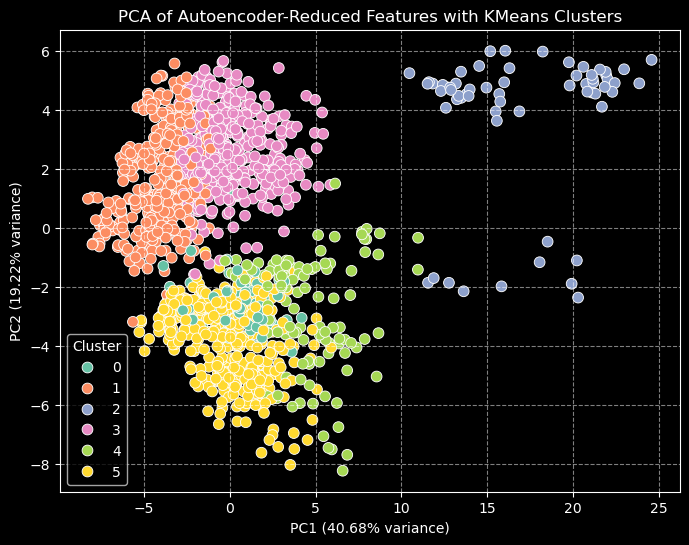

In [189]:
## Plot your pca scatterplot with clusters as the hue
plt.figure(figsize=(8,6))
sns.scatterplot(
x='PC1',
y='PC2',
hue='Cluster',
data=pca_reduced_df,
palette='Set2',
s=60
)
plt.title('PCA of Autoencoder-Reduced Features with KMeans Clusters')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()